<div style="background:linear-gradient(135deg,#14b8a6 0%,#6366f1 100%);color:#ffffff;padding:26px 30px;border-radius:16px;font-family:'Segoe UI',Arial,sans-serif;">
  <div style="letter-spacing:.18em;font-size:12px;text-transform:uppercase;opacity:.85;">DS Elective 4 &nbsp;•&nbsp; Deep Learning</div>
  <div style="font-size:30px;font-weight:700;margin:6px 0 2px;">Laboratory Task 4</div>
  <div style="font-size:18px;opacity:.95;">Linear Regression in PyTorch</div>
  <div style="font-size:13px;opacity:.8;margin-top:10px;">Training a 2-layer fully connected regression model with MSE loss and SGD</div>
</div>

**Name:** Edrian C. Jugan


# Task 4: Linear Regression in PyTorch

## 📌 Problem Statement

> **Instruction:** Train a linear regression model in PyTorch using a regression dataset. Use the following parameters.

| Requirement | Setting used |
|---|---|
| Criterion | `nn.MSELoss()` |
| Fully connected layers | 2 × `nn.Linear` (10 → 16 → 1) |
| Batch size | 8 |
| Optimizer | `torch.optim.SGD` (learning rate 0.01) |
| Epochs | 1000 |

**Dataset:** the *Diabetes* dataset from scikit-learn (442 patients, 10 features such as age, BMI and blood pressure). The target is a number that measures disease progression one year after baseline, so this is a regression problem. It ships with scikit-learn, so no download is needed.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# consistent look for every plot in this notebook
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "font.size": 11,
})
TEAL, INDIGO, RED, ORANGE, GREY = "#14b8a6", "#6366f1", "#ef4444", "#f97316", "#94a3b8"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [2]:
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)   # so the results can be reproduced

## 1️⃣ Load and explore the dataset

In [3]:
data = load_diabetes()
X = data.data                     # (442, 10)
y = data.target.reshape(-1, 1)    # (442, 1)

df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y
print(f"Samples: {X.shape[0]} | Features: {X.shape[1]} | Target range: {y.min():.0f} to {y.max():.0f}")
df.head()

Samples: 442 | Features: 10 | Target range: 25 to 346


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


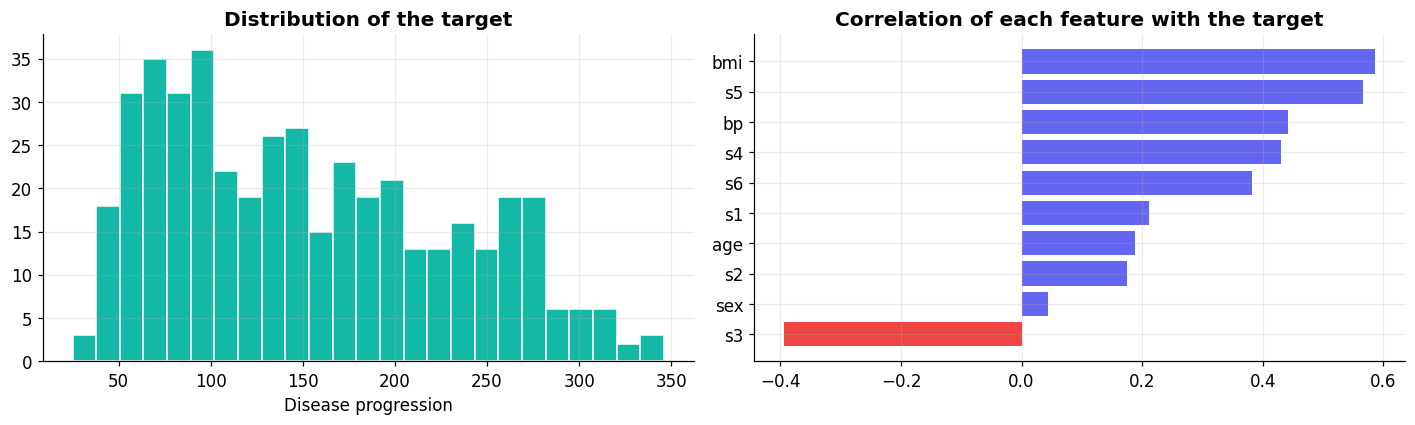

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(y, bins=25, color=TEAL, edgecolor="white")
axes[0].set_title("Distribution of the target"); axes[0].set_xlabel("Disease progression")

corr = df.corr()["target"].drop("target").sort_values()
axes[1].barh(corr.index, corr.values, color=[RED if v < 0 else INDIGO for v in corr.values])
axes[1].set_title("Correlation of each feature with the target")

plt.tight_layout()
plt.show()

## 2️⃣ Prepare the data (input and target)

- Split: **80% training / 20% testing**.
- **Standardize** the inputs and the target using only the training statistics. SGD trains much more smoothly when everything is on a similar scale.
- Convert everything to `float32` tensors.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

x_scaler, y_scaler = StandardScaler(), StandardScaler()
X_train_s = x_scaler.fit_transform(X_train)
X_test_s  = x_scaler.transform(X_test)
y_train_s = y_scaler.fit_transform(y_train)

inputs   = torch.tensor(X_train_s, dtype=torch.float32)
targets  = torch.tensor(y_train_s, dtype=torch.float32)
X_test_t = torch.tensor(X_test_s,  dtype=torch.float32)

print("Train inputs :", inputs.shape, "| Train targets:", targets.shape)
print("Test inputs  :", X_test_t.shape)

Train inputs : torch.Size([353, 10]) | Train targets: torch.Size([353, 1])
Test inputs  : torch.Size([89, 10])


## 3️⃣ Dataset and DataLoader (batch size = 8)

In [6]:
train_ds = TensorDataset(inputs, targets)

batch_size = 8
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

xb, yb = next(iter(train_dl))
print("One batch ->", xb.shape, yb.shape)
print("Batches per epoch:", len(train_dl))

One batch -> torch.Size([8, 10]) torch.Size([8, 1])
Batches per epoch: 45


## 4️⃣ Define the model: 2 fully connected layers

$$\underbrace{x}_{10} \;\longrightarrow\; \text{FC}_1\;(10\to16) \;\longrightarrow\; \text{FC}_2\;(16\to1) \;\longrightarrow\; \hat{y}$$

There is no activation function between the two layers, so the whole model is still a **linear** regression (two stacked linear layers make another linear function). To make it non-linear you can put an `nn.ReLU()` between them.

In [7]:
class LinearRegressionModel(nn.Module):
    def __init__(self, in_features=10, hidden=16, out_features=1):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden)    # fully connected layer 1
        self.fc2 = nn.Linear(hidden, out_features)   # fully connected layer 2

    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        return x

model = LinearRegressionModel().to(device)
print(model)
print("\nTrainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

LinearRegressionModel(
  (fc1): Linear(in_features=10, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)

Trainable parameters: 193


## 5️⃣ Loss function (MSE) and optimizer (SGD)

In [8]:
criterion = nn.MSELoss()
opt = torch.optim.SGD(model.parameters(), lr=0.01)

## 6️⃣ Train for 1000 epochs

Every step of every batch does the same four things:

1. **Predict** with the model
2. **Calculate the loss** (MSE)
3. **Calculate the gradients** with `loss.backward()`
4. **Update the parameters** with `opt.step()`

In [9]:
def fit(num_epochs, model, loss_fn, opt, train_dl):
    history = []
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)

            pred = model(xb)              # 1. predict
            loss = loss_fn(pred, yb)      # 2. calculate loss

            opt.zero_grad()               # 3. calculate gradients
            loss.backward()

            opt.step()                    # 4. update parameters

            running_loss += loss.item() * xb.size(0)

        epoch_loss = running_loss / len(train_dl.dataset)
        history.append(epoch_loss)

        if epoch == 0 or (epoch + 1) % 100 == 0:
            print(f"Epoch [{epoch + 1:>4}/{num_epochs}]  Loss: {epoch_loss:.4f}")
    return history

history = fit(1000, model, criterion, opt, train_dl)

Epoch [   1/1000]  Loss: 0.7381
Epoch [ 100/1000]  Loss: 0.4887
Epoch [ 200/1000]  Loss: 0.4826
Epoch [ 300/1000]  Loss: 0.4812
Epoch [ 400/1000]  Loss: 0.4802
Epoch [ 500/1000]  Loss: 0.4803
Epoch [ 600/1000]  Loss: 0.4810
Epoch [ 700/1000]  Loss: 0.4784
Epoch [ 800/1000]  Loss: 0.4816
Epoch [ 900/1000]  Loss: 0.4802
Epoch [1000/1000]  Loss: 0.4806


## 📉 Training curve

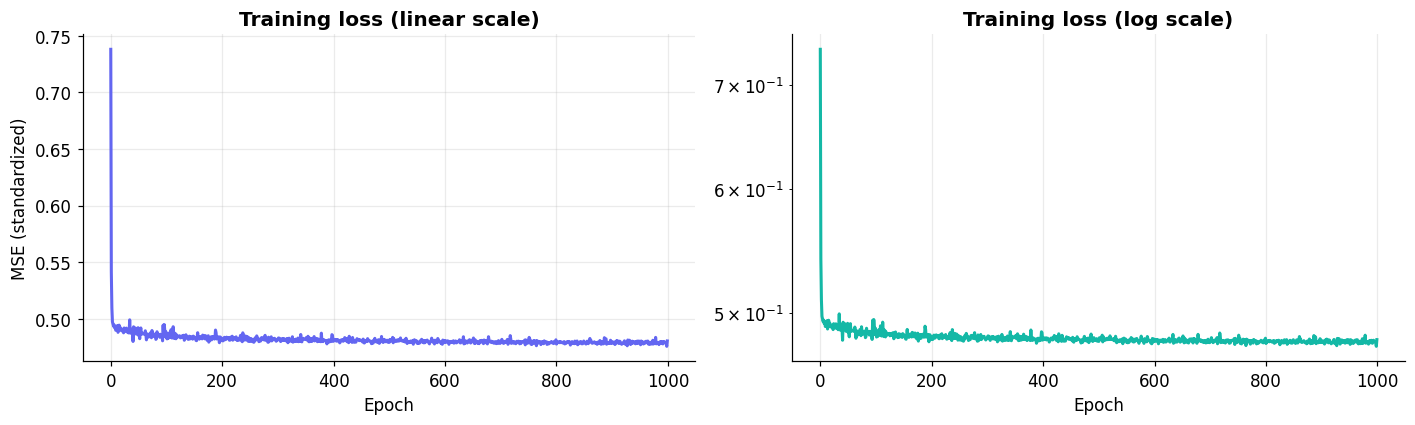

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history, color=INDIGO, lw=2)
axes[0].set_title("Training loss (linear scale)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE (standardized)")

axes[1].plot(history, color=TEAL, lw=2)
axes[1].set_yscale("log")
axes[1].set_title("Training loss (log scale)")
axes[1].set_xlabel("Epoch")

plt.tight_layout()
plt.show()

## 🧪 Evaluate on the test set

The model predicts on the standardized scale, so we convert the predictions back to the original units before computing the metrics.

In [11]:
model.eval()
with torch.no_grad():
    preds_s = model(X_test_t.to(device)).cpu().numpy()

preds = y_scaler.inverse_transform(preds_s)

mse  = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, preds)

print(f"Test MSE  : {mse:.2f}")
print(f"Test RMSE : {rmse:.2f}")
print(f"Test R^2  : {r2:.4f}")

Test MSE  : 2942.25
Test RMSE : 54.24
Test R^2  : 0.4447


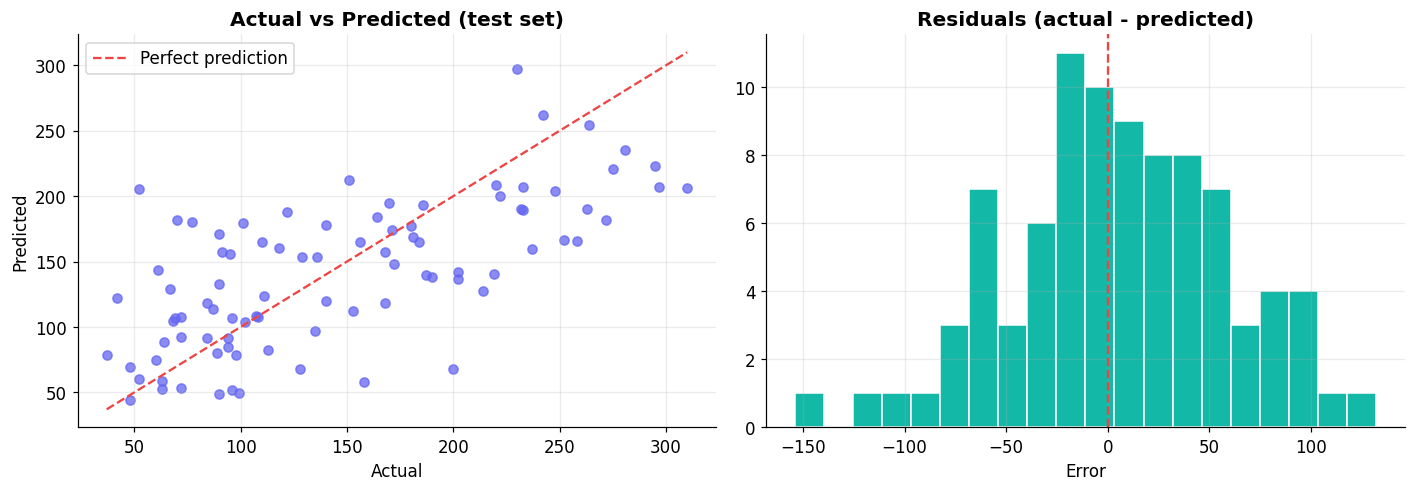

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# actual vs predicted
axes[0].scatter(y_test, preds, alpha=0.75, color=INDIGO)
lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
axes[0].plot(lims, lims, "--", color=RED, label="Perfect prediction")
axes[0].set_xlabel("Actual"); axes[0].set_ylabel("Predicted")
axes[0].set_title("Actual vs Predicted (test set)"); axes[0].legend()

# residuals
residuals = (y_test - preds).ravel()
axes[1].hist(residuals, bins=20, color=TEAL, edgecolor="white")
axes[1].axvline(0, color=RED, ls="--")
axes[1].set_title("Residuals (actual - predicted)"); axes[1].set_xlabel("Error")

plt.tight_layout()
plt.show()

## 🔍 Sanity check against scikit-learn
Since our model is linear, it should land close to the closed-form least squares solution.

In [13]:
sk = LinearRegression().fit(X_train_s, y_train_s)
sk_preds = y_scaler.inverse_transform(sk.predict(X_test_s))

results = pd.DataFrame({
    "Model": ["PyTorch (2 FC layers, SGD)", "scikit-learn LinearRegression"],
    "Test MSE": [mse, mean_squared_error(y_test, sk_preds)],
    "Test RMSE": [rmse, np.sqrt(mean_squared_error(y_test, sk_preds))],
    "Test R^2": [r2, r2_score(y_test, sk_preds)],
}).round(4)
results

,Model,Test MSE,Test RMSE,Test R^2
0,"PyTorch (2 FC layers, SGD)",2942.2495,54.2425,0.4447
1,scikit-learn LinearRegression,2900.1936,53.8534,0.4526
